In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed 
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python 
#%pip install tensorflow

import tensorflow as tf 
import matplotlib.pyplot as plt 
import seaborn as sn 
import numpy as np # linear algebra 
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv) 
import math 
import datetime 
import platform 

# Input data files are available in the read-only "../input/" directory 
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory 
import os 

for dirname, _, filenames in os.walk('/kaggle/input'):  
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [ ]:
('Python version:', platform.python_version()) 
('Tensorflow version:', tf.__version__) 
('Keras version:', tf.keras.__version__) 

# Load the TensorBoard notebook extension. 
# %reload_ext tensorboard 
%load_ext tensorboard 

# Clear any logs from previous runs. 
!rm -rf ./.logs/ 

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


'rm' is not recognized as an internal or external command,
operable program or batch file.


In [ ]:
train = pd.read_csv("E:\\Imp Files\\Projects\\Handwritten Digit Recogination\\train.csv")
test = pd.read_csv("E:\\Imp Files\\Projects\\Handwritten Digit Recogination\\test.csv")

In [ ]:
train.head() 

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
train.info(), train.shape 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42000 entries, 0 to 41999
Columns: 785 entries, label to pixel783
dtypes: int64(785)
memory usage: 251.5 MB


(None, (42000, 785))

In [ ]:
test.info(), test.shape 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28000 entries, 0 to 27999
Columns: 784 entries, pixel0 to pixel783
dtypes: int64(784)
memory usage: 167.5 MB


(None, (28000, 784))

In [32]:
X = train.iloc[:, 1:785]
y = train.iloc[:, 0]

X_test = test.iloc[:, 0:784]

In [ ]:
X_tsn = X/255

from sklearn.manifold import TSNE
tsne = TSNE()

tsne_res = tsne.fit_transform(X_tsn)

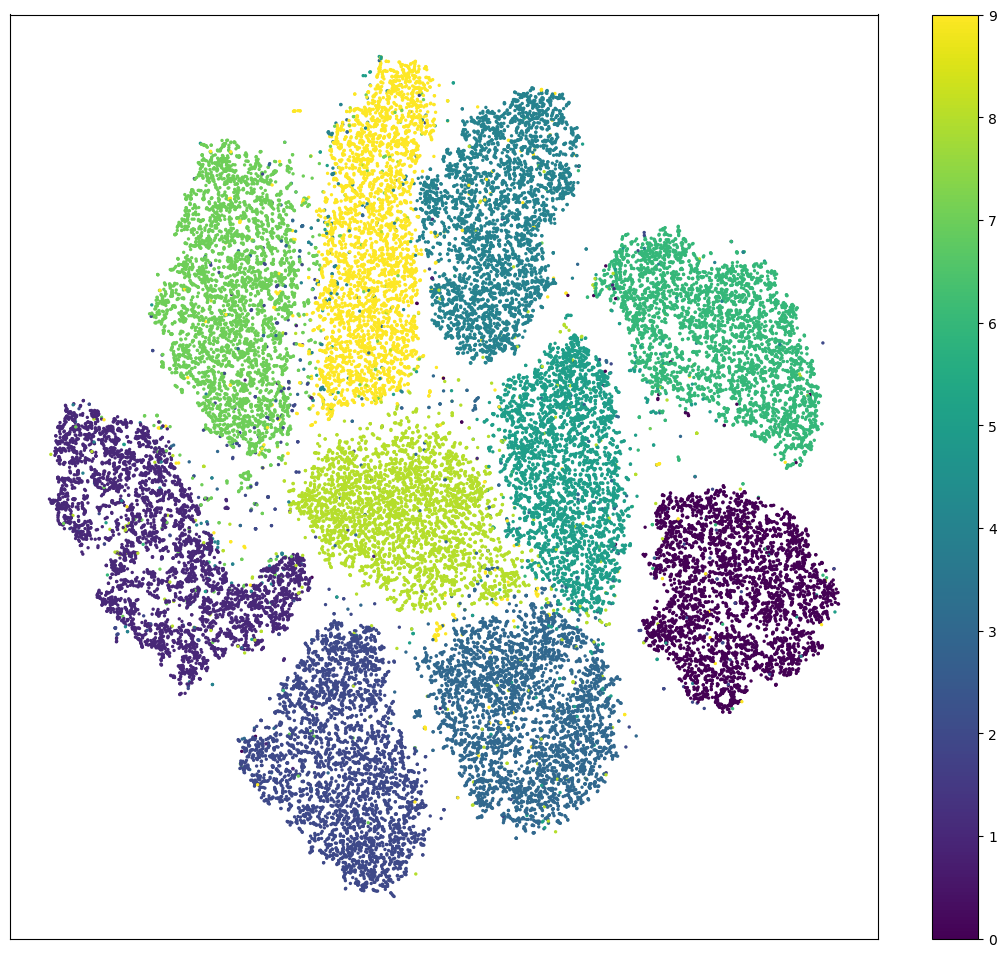

In [ ]:
plt.figure(figsize=(14, 12)) 
plt.scatter(tsne_res[:,0], tsne_res[:,1], c=y, s=2) 
plt.xticks([]) 
plt.yticks([]) 
plt.colorbar(); 

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_validation, y_train, y_validation = train_test_split(
    X, y, test_size=0.2, random_state=1212
)

In [ ]:
('X_train:', X_train.shape) 
('y_train:', y_train.shape) 
('X_validation:', X_validation.shape) 
('y_validation:', y_validation.shape) 

('y_validation:', (8400,))

In [ ]:
x_train_re = X_train.to_numpy().reshape(33600, 28, 28) 
y_train_re = y_train.values 
x_validation_re = X_validation.to_numpy().reshape(8400, 28, 28) 
y_validation_re = y_validation.values 
x_test_re = test.to_numpy().reshape(28000, 28, 28) 

In [ ]:
('x_train:', x_train_re.shape) 
('y_train:', y_train_re.shape) 
('x_validation:', x_validation_re.shape) 
('y_validation:', y_validation_re.shape) 
('x_test:', x_test_re.shape) 

('x_test:', (28000, 28, 28))

In [ ]:
# Save image parameters to the constants that we will use later for data re-shaping and for model traning. 
(_, IMAGE_WIDTH, IMAGE_HEIGHT) = x_train_re.shape 
IMAGE_CHANNELS = 1 
('IMAGE_WIDTH:', IMAGE_WIDTH); 
('IMAGE_HEIGHT:', IMAGE_HEIGHT); 
('IMAGE_CHANNELS:', IMAGE_CHANNELS); 

In [ ]:
pd.DataFrame(x_train_re[0]) 

,0,1,2,3,4,5,6,7,8,9,...,18,19,20,21,22,23,24,25,26,27
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,155,155,12,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,...,254,254,103,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,0,0,0,...,254,254,55,0,0,0,0,0,0,0
7,0,0,0,0,0,0,0,0,0,0,...,254,254,20,0,0,0,0,0,0,0
8,0,0,0,0,0,0,0,0,0,0,...,254,170,6,0,0,0,0,0,0,0
9,0,0,0,0,0,0,0,0,0,0,...,242,37,0,0,0,0,0,0,0,0


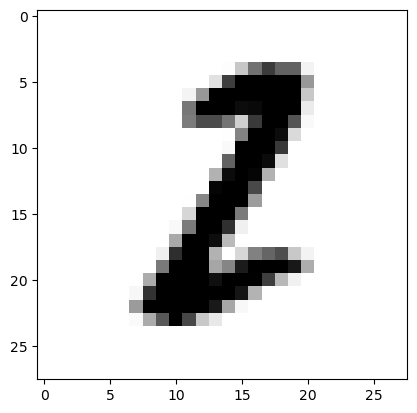

In [ ]:
plt.imshow(x_train_re[0], cmap=plt.cm.binary) 
plt.show() 

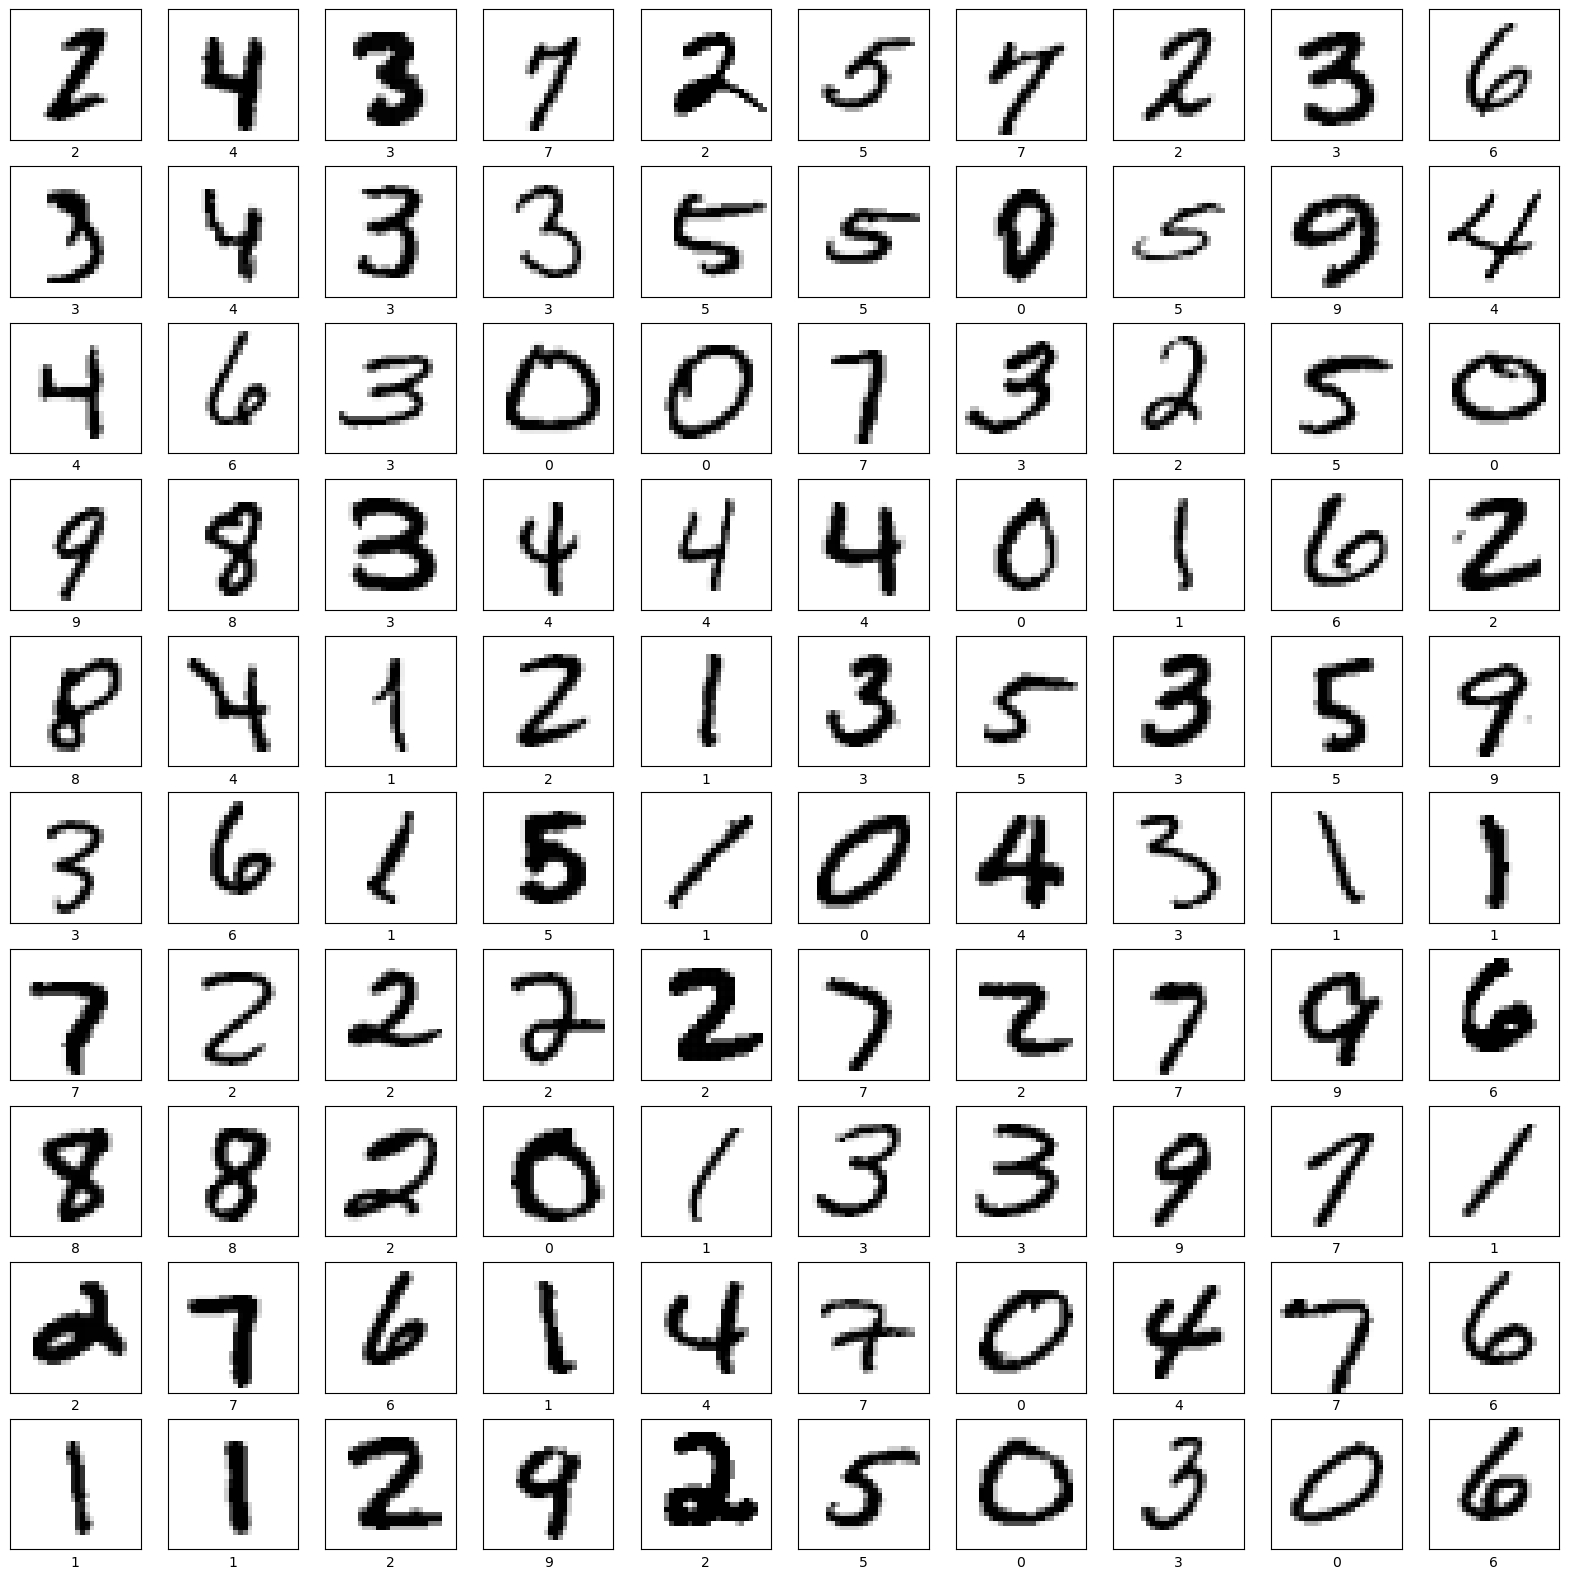

In [ ]:
import math
import matplotlib.pyplot as plt

numbers_to_display = 100  # Number of images to display
num_cells = math.ceil(math.sqrt(numbers_to_display))  # Calculate grid size

plt.figure(figsize=(20, 20))

# Loop over the range of images to display
for i in range(numbers_to_display):  # Corrected loop
    plt.subplot(num_cells, num_cells, i+1)  # Create subplot
    plt.xticks([])  # Remove x-axis ticks
    plt.yticks([])  # Remove y-axis ticks
    plt.grid(False)  # Turn off the grid
    plt.imshow(x_train_re[i], cmap=plt.cm.binary)  # Display image
    plt.xlabel(y_train_re[i])  # Display the corresponding label
plt.show()  # Show all images

In [ ]:
x_train_with_chanels = x_train_re.reshape( x_train_re.shape[0], 
IMAGE_WIDTH, IMAGE_HEIGHT, IMAGE_CHANNELS ) 

x_validation_with_chanels = x_validation_re.reshape( x_validation_re.shape[0], 
IMAGE_WIDTH, IMAGE_HEIGHT, IMAGE_CHANNELS ) 

x_test_with_chanels = x_test_re.reshape( x_test_re.shape[0], IMAGE_WIDTH, 
IMAGE_HEIGHT, IMAGE_CHANNELS ) 

In [ ]:
('x_train_with_chanels:', x_train_with_chanels.shape) 
('x_validation_with_chanels:', x_validation_with_chanels.shape) 
('x_test_with_chanels:', x_test_with_chanels.shape) 

('x_test_with_chanels:', (28000, 28, 28, 1))

In [ ]:
x_train_normalized = x_train_with_chanels / 255 
x_validation_normalized = x_validation_with_chanels / 255 
x_test_normalized = x_test_with_chanels / 255 

# Let's check just one row from the 0th image to see color chanel values after normalization. 
x_train_normalized[0][10] 

array([[0.        ],
       [0.        ],
       [0.        ],
       [0.        ],
       [0.        ],
       [0.        ],
       [0.        ],
       [0.        ],
       [0.        ],
       [0.        ],
       [0.        ],
       [0.        ],
       [0.        ],
       [0.        ],
       [0.02352941],
       [0.99607843],
       [0.99607843],
       [0.99607843],
       [0.76862745],
       [0.        ],
       [0.        ],
       [0.        ],
       [0.        ],
       [0.        ],
       [0.        ],
       [0.        ],
       [0.        ],
       [0.        ]])

In [ ]:
model = tf.keras.models.Sequential() 
model.add(tf.keras.layers.Convolution2D( 
	input_shape=(IMAGE_WIDTH, IMAGE_HEIGHT, IMAGE_CHANNELS), 
	kernel_size=5, filters=8, strides=1, activation=tf.keras.activations.relu, 
	kernel_initializer=tf.keras.initializers.VarianceScaling() )) 
model.add(tf.keras.layers.MaxPooling2D( pool_size=(2, 2), strides=(2, 2) ))

model.add(tf.keras.layers.Convolution2D( kernel_size=5, filters=16, strides=1, activation=tf.keras.activations.relu, kernel_initializer=tf.keras.initializers.VarianceScaling() )) 

model.add(tf.keras.layers.MaxPooling2D( pool_size=(2, 2), strides=(2, 2) )) 
model.add(tf.keras.layers.Flatten()) 

model.add(tf.keras.layers.Dense( units=128, activation=tf.keras.activations.relu ));
 
model.add(tf.keras.layers.Dropout(0.2))

model.add(tf.keras.layers.Dense( units=10, activation=tf.keras.activations.softmax, 
kernel_initializer=tf.keras.initializers.VarianceScaling() )) 

c:\Users\karan ray\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary() 

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 24, 24, 8)      │           208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 12, 12, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 8, 8, 16)       │         3,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 4, 4, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 37,610 (146.91 KB)

 Trainable params: 37,610 (146.91 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
tf.keras.utils.plot_model( model, show_shapes=True, show_layer_names=True, ) 

You must install pydot (`pip install pydot`) for `plot_model` to work.


In [54]:
adam_optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)  # Adam optimizer with learning rate
model.compile(optimizer=adam_optimizer, 
              loss=tf.keras.losses.sparse_categorical_crossentropy, 
              metrics=['accuracy'])  # Compile the model with Adam optimizer


In [ ]:
import datetime

# Define log directory with current timestamp
log_dir = ".logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")

# Set up the TensorBoard callback
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)

# Train the model
training_history = model.fit(
    x_train_normalized, y_train_re,
    epochs=10,
    validation_data=(x_validation_normalized, y_validation_re),
    callbacks=[tensorboard_callback]
)

# Print success message
print("The model has successfully trained")

Epoch 1/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8152 - loss: 0.6034 - val_accuracy: 0.9781 - val_loss: 0.0715
Epoch 2/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.9745 - loss: 0.0842 - val_accuracy: 0.9856 - val_loss: 0.0490
Epoch 3/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9822 - loss: 0.0596 - val_accuracy: 0.9854 - val_loss: 0.0493
Epoch 4/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.9865 - loss: 0.0429 - val_accuracy: 0.9861 - val_loss: 0.0456
Epoch 5/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9896 - loss: 0.0327 - val_accuracy: 0.9843 - val_loss: 0.0549
Epoch 6/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9915 - loss: 0.0272 - val_accuracy: 0.9876 - val_loss: 0.0401
Epoch 7/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9927 - loss: 0.0246 - val_accuracy: 0.9888 - val_loss: 0.0411
Epoch 8/10
1050/1050 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9938 - loss: 0.0204 - 

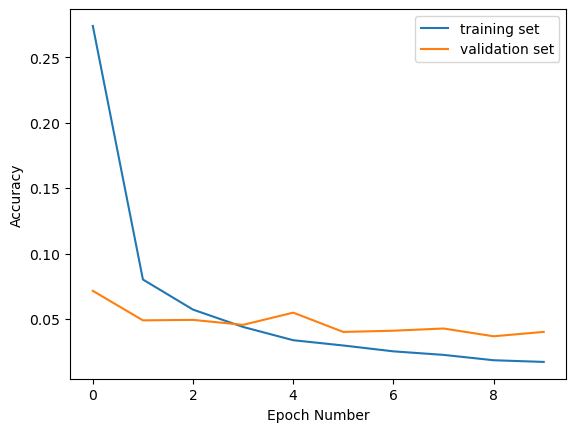

In [ ]:
plt.xlabel('Epoch Number')
plt.ylabel('Accuracy')  
plt.plot(training_history.history['loss'], label='training set') 
plt.plot(training_history.history['val_loss'], label='validation set') 
plt.legend()

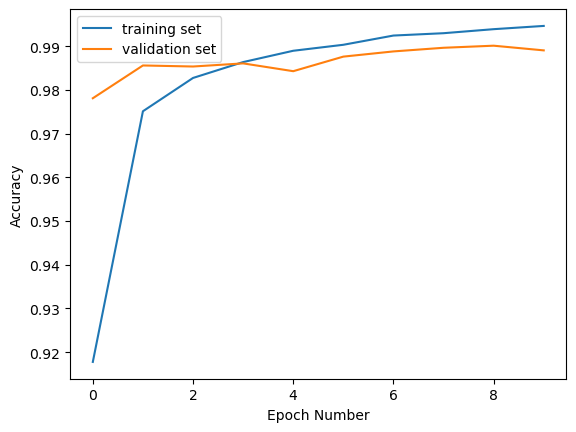

In [61]:
plt.xlabel('Epoch Number') 
plt.ylabel('Accuracy') 
plt.plot(training_history.history['accuracy'], label='training set') 
plt.plot(training_history.history['val_accuracy'], label='validation set') 
plt.legend() 

In [62]:
%%capture 
train_loss, train_accuracy = model.evaluate(x_train_normalized, y_train_re) 

('Train loss: ', train_loss) 
('Train accuracy: ', train_accuracy) 

In [63]:
%%capture 
validation_loss, validation_accuracy = model.evaluate(x_validation_normalized, y_validation_re) 

('Validation loss: ', validation_loss) 
('Validation accuracy: ', validation_accuracy) 

In [65]:
model_name = 'digits_recognition_cnn.h5' 
model.save(model_name, save_format='h5') 

loaded_model = tf.keras.models.load_model(model_name) 

In [66]:
predictions_one_hot = loaded_model.predict([x_validation_normalized]) 
('predictions_one_hot:', predictions_one_hot.shape) 

 40/263 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

c:\Users\karan ray\anaconda3\Lib\site-packages\keras\src\models\functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer
Received: inputs=('Tensor(shape=(32, 28, 28, 1))',)
  warnings.warn(msg)


263/263 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


c:\Users\karan ray\anaconda3\Lib\site-packages\keras\src\models\functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer
Received: inputs=('Tensor(shape=(None, 28, 28, 1))',)
  warnings.warn(msg)


('predictions_one_hot:', (8400, 10))

In [ ]:
# Predictions in form of one-hot vectors (arrays of probabilities). 
pd.DataFrame(predictions_one_hot) 

,0,1,2,3,4,5,6,7,8,9
0,1.721294e-09,9.999998e-01,2.178425e-08,2.196692e-15,7.396851e-08,6.261246e-11,2.573532e-09,5.037293e-11,1.876710e-07,2.303161e-10
1,1.246810e-13,3.564236e-09,3.481438e-09,9.999926e-01,2.233999e-11,6.047365e-06,2.123118e-12,1.436856e-08,9.166213e-07,3.697532e-07
2,8.344682e-12,1.339769e-10,3.739840e-08,1.031339e-06,5.615787e-10,7.191604e-08,6.782323e-10,4.514777e-11,9.999989e-01,6.488030e-09
3,1.334047e-08,9.999945e-01,4.893910e-08,8.121519e-11,5.205395e-06,2.068465e-08,1.437610e-08,6.062383e-08,1.225117e-07,1.089676e-08
4,7.322635e-13,6.002151e-13,4.229884e-09,8.440320e-09,8.878832e-04,1.346399e-07,3.928751e-14,2.112487e-06,4.346785e-05,9.990664e-01
...,...,...,...,...,...,...,...,...,...,...
8395,3.680658e-18,2.119453e-11,1.654526e-13,1.148207e-18,1.000000e+00,3.588454e-15,5.437715e-16,3.401592e-14,3.764719e-13,6.155767e-10
8396,6.868117e-14,7.201315e-16,6.148005e-19,3.585949e-08,4.012773e-15,9.999981e-01,3.331018e-07,7.004019e-18,1.552681e-06,5.741034e-14
8397,1.987126e-11,3.641911e-12,5.115334e-10,1.093582e-14,4.343715e-09,2.999566e-10,1.592511e-17,9.999999e-01,1.988838e-13,1.185381e-07
8398,1.337584e-07,2.164034e-12,1.453301e-13,2.745168e-14,3.436202e-08,3.246067e-08,9.999998e-01,1.325411e-15,1.405196e-08,7.530090e-12


In [ ]:
# Let's extract predictions with highest probabilites and detect what digits have been recognized. 
predictions = np.argmax(predictions_one_hot, axis=1) 
pd.DataFrame(predictions) 

,0
0,1
1,3
2,8
3,1
4,9
...,...
8395,4
8396,5
8397,7
8398,6


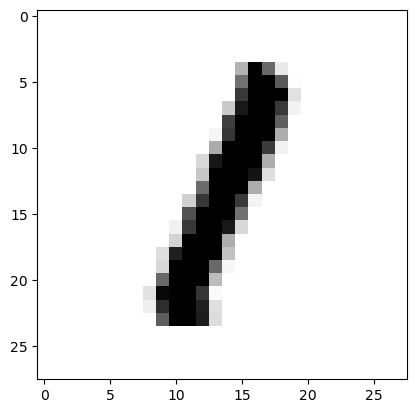

In [ ]:
plt.imshow(x_validation_normalized[0].reshape((IMAGE_WIDTH, IMAGE_HEIGHT)), 
cmap=plt.cm.binary) 
plt.show() 

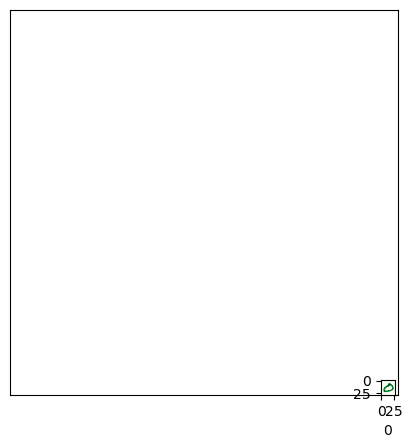

In [77]:
import math

numbers_to_display = 196
num_cells = math.ceil(math.sqrt(numbers_to_display))

 
plt.figure(figsize=(5, 5))
for plot_index in range(numbers_to_display):
    predicted_label = predictions[plot_index]

plt.xticks([]) 
plt.yticks([]) 
plt.grid(False) 

color_map = 'Greens' if predicted_label == y_validation_re[plot_index] else 'Reds'
plt.subplot(num_cells, num_cells, plot_index + 1) 
plt.imshow(x_validation_normalized[plot_index].reshape((IMAGE_WIDTH, IMAGE_HEIGHT)), 
cmap=color_map) 

plt.xlabel(predicted_label) 

plt.subplots_adjust(hspace=1, wspace=0.5)
plt.show() 

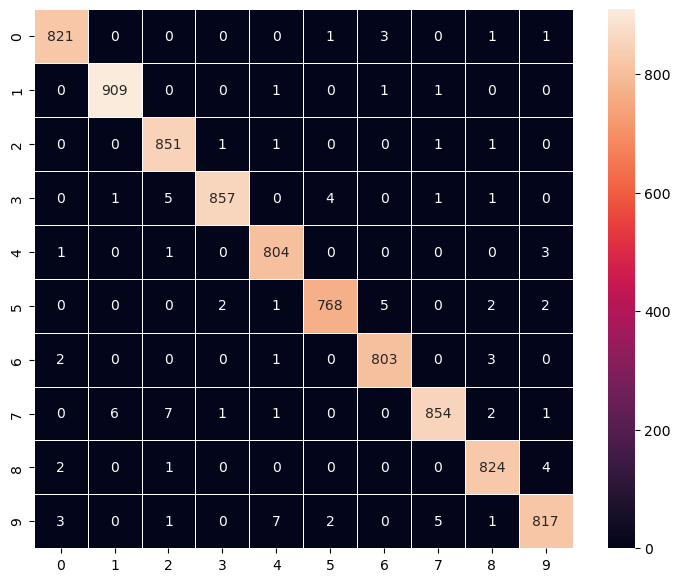

In [79]:
confusion_matrix = tf.math.confusion_matrix(y_validation_re, predictions)
f, ax = plt.subplots(figsize=(9, 7))
sn.heatmap(
    confusion_matrix,
    annot=True,
    linewidths=.5,
    fmt="d",
    square=True,
    ax=ax
)
plt.show()

In [80]:
predictions_one_hot = loaded_model.predict([x_test_normalized]) 
print('predictions_one_hot:', predictions_one_hot.shape) 


875/875 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
predictions_one_hot: (28000, 10)


In [81]:
pd.DataFrame(predictions_one_hot) 


,0,1,2,3,4,5,6,7,8,9
0,2.597764e-11,1.630004e-12,1.000000e+00,3.733748e-13,1.400018e-11,1.406744e-16,1.736474e-16,4.412856e-11,1.217213e-11,1.403430e-14
1,9.998822e-01,4.924723e-10,1.558691e-05,2.981234e-11,1.464377e-08,4.779599e-07,1.166311e-06,2.075246e-05,1.613323e-09,7.977863e-05
2,1.490874e-11,3.027991e-10,1.837923e-08,1.601854e-07,4.252650e-04,2.260737e-07,1.798305e-12,2.146920e-07,2.244741e-05,9.995516e-01
3,9.216096e-01,2.510394e-12,2.223350e-06,2.133272e-08,2.939104e-06,1.176541e-09,8.099227e-07,1.618371e-07,9.264003e-06,7.837489e-02
4,4.214228e-14,3.432748e-11,5.871632e-08,9.999874e-01,2.020338e-15,7.601637e-10,1.239639e-13,5.741649e-11,1.262584e-05,9.585713e-11
...,...,...,...,...,...,...,...,...,...,...
27995,7.188239e-13,1.019450e-15,8.390362e-11,6.952754e-10,8.862584e-06,2.402901e-08,6.281681e-15,9.068663e-08,2.773450e-09,9.999911e-01
27996,3.123624e-09,5.587972e-10,1.613511e-07,1.319468e-10,1.232687e-08,5.972595e-09,2.772240e-15,9.999946e-01,1.473190e-12,5.297079e-06
27997,1.541998e-22,1.027208e-15,7.295258e-15,1.000000e+00,3.331644e-20,2.770890e-12,2.837912e-21,4.218604e-12,4.266645e-13,4.555137e-13
27998,1.506198e-10,1.052117e-11,1.025389e-08,4.323819e-09,4.092951e-04,5.721395e-08,2.070555e-13,7.984767e-07,7.857940e-09,9.995899e-01


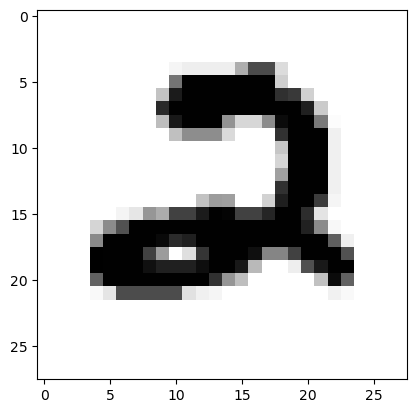

In [82]:
plt.imshow(x_test_normalized[0].reshape((IMAGE_WIDTH, IMAGE_HEIGHT)), cmap=plt.cm.binary) 
plt.show() 


In [ ]:
test_pred = pd.DataFrame( loaded_model.predict([x_test_normalized])) 
test_pred = pd.DataFrame(test_pred.idxmax(axis = 1)) 
test_pred.index.name = 'ImageId' 
test_pred = test_pred.rename(columns = {0: 'Label'}).reset_index() 
test_pred['ImageId'] = test_pred['ImageId'] + 1 
test_pred.head() 

875/875 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step


,ImageId,Label
0,1,2
1,2,0
2,3,9
3,4,0
4,5,3


In [ ]:
test_pred.to_csv('submission.csv', index = False) 